In [ ]:
# Šioje celėje importuojamos visos reikalingos bibliotekos: duomenų apdorojimui, grafikams,
# darbui su failais, PyTorch neuroniniam tinklui, taip pat ROUGE ir BERTScore metrikoms

import json
import math
import random
import re
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from tqdm import tqdm

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from rouge_score import rouge_scorer
from bert_score import score as bertscore_score

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Čia aprašoma Config klasė, kurioje vienoje vietoje saugomi visi pagrindiniai nustatymai:
# duomenų failų keliai, stulpelių pavadinimai, modelio hiperparametrai, mokymo parametrai,
# rezultatų saugojimo vieta ir įrenginys (CPU arba GPU).

@dataclass
class Config:
    train_csv: str = r"C:\\bakis\\duomenys\\samsum-train.csv"
    val_csv: str = r"C:\\bakis\\duomenys\\samsum-validation.csv"
    test_csv: str = r"C:\\bakis\\duomenys\\samsum-test.csv"

    text_column: str = "dialogue"
    summary_column: str = "summary"

    output_dir: str = r"C:\\bakis\\PALYGINIMAS\\lstm"

    use_train_subset: bool = True
    train_subset_size: int = 5000
    subset_random_state: int = 42

    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # tokenizacija / sekų ilgiai
    min_freq: int = 2
    max_src_len: int = 512
    max_tgt_len: int = 80

    # modelis
    emb_dim: int = 300
    hidden_dim: int = 768
    num_layers: int = 2
    dropout: float = 0.3

    # mokymas
    batch_size: int = 16
    num_epochs: int = 20
    lr: float = 5e-4
    weight_decay: float = 1e-5
    grad_clip: float = 1.0
    teacher_forcing_ratio: float = 0.7

    # early stopping
    patience: int = 3

    # inference
    max_generation_len: int = 80

    # output
    save_predictions_csv: bool = True
    make_plots: bool = True
    dpi: int = 160

    # bertscore
    bertscore_model_type: str = "bert-base-uncased"
    bertscore_lang: str = "en"
    compute_bertscore_on_test: bool = True
    bertscore_batch_size: int = 16

cfg = Config()
cfg

Config(train_csv='C:\\\\bakis\\\\duomenys\\\\samsum-train.csv', val_csv='C:\\\\bakis\\\\duomenys\\\\samsum-validation.csv', test_csv='C:\\\\bakis\\\\duomenys\\\\samsum-test.csv', text_column='dialogue', summary_column='summary', output_dir='C:\\\\bakis\\\\PALYGINIMAS\\\\lstm', use_train_subset=True, train_subset_size=5000, subset_random_state=42, seed=42, device='cuda', min_freq=2, max_src_len=512, max_tgt_len=80, emb_dim=300, hidden_dim=768, num_layers=2, dropout=0.3, batch_size=16, num_epochs=20, lr=0.0005, weight_decay=1e-05, grad_clip=1.0, teacher_forcing_ratio=0.7, patience=3, max_generation_len=80, save_predictions_csv=True, make_plots=True, dpi=160, bertscore_model_type='bert-base-uncased', bertscore_lang='en', compute_bertscore_on_test=True, bertscore_batch_size=16)

In [ ]:
# Šioje celėje apibrėžiamos pagalbinės funkcijos. set_seed užtikrina, kad eksperimentas būtų
# atkartojamas, ensure_dir sukuria aplankus rezultatams, normalize_text sutvarko tekstą,
# simple_tokenize suskaido tekstą į žetonus, o kitos funkcijos padeda skaičiuoti
# ilgius ir saugiai apskaičiuoti vidurkius.

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)


def ensure_dir(path):
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p


def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text


def simple_tokenize(text):
    text = normalize_text(text).lower()
    # žodžiai + skyryba kaip atskiri tokenai
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)


def word_count(text):
    text = normalize_text(text)
    return len(text.split()) if text else 0


def safe_mean(values):
    values = list(values)
    return float(np.mean(values)) if len(values) > 0 else 0.0

In [ ]:
# Šioje celėje įkeliami mokymo, validacijos ir testavimo duomenys iš CSV failų. Funkcija
# patikrina, ar egzistuoja reikalingi stulpeliai, normalizuoja tekstą
# ir prireikus sumažina mokymo rinkinį iki nurodyto dydžio, kad modelį būtų galima greičiau
# apmokyti.

def load_single_dataset(csv_path, cfg):
    df = pd.read_csv(csv_path)

    if cfg.text_column not in df.columns:
        raise ValueError(f"Nerastas teksto stulpelis: {cfg.text_column}")
    if cfg.summary_column not in df.columns:
        raise ValueError(f"Nerastas santraukos stulpelis: {cfg.summary_column}")

    df = df[[cfg.text_column, cfg.summary_column]].copy()
    df[cfg.text_column] = df[cfg.text_column].apply(normalize_text)
    df[cfg.summary_column] = df[cfg.summary_column].apply(normalize_text)

    df = df[
        (df[cfg.text_column] != "") &
        (df[cfg.summary_column] != "")
    ].reset_index(drop=True)

    return df


def maybe_take_train_subset(df, cfg):
    if not cfg.use_train_subset:
        return df.reset_index(drop=True)

    subset_size = min(cfg.train_subset_size, len(df))
    return df.sample(n=subset_size, random_state=cfg.subset_random_state).reset_index(drop=True)


full_train_df = load_single_dataset(cfg.train_csv, cfg)
val_df = load_single_dataset(cfg.val_csv, cfg)
test_df = load_single_dataset(cfg.test_csv, cfg)

train_df = maybe_take_train_subset(full_train_df, cfg)

print("Full train:", len(full_train_df))
print("Used train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Full train: 14731
Used train: 5000
Validation: 818
Test: 819


In [6]:
# Ši celė išveda pagrindinę duomenų rinkinių statistiką: kiek yra pavyzdžių ir koks vidutinis
# dialogo bei santraukos ilgis žodžiais. Tai padeda suprasti, su kokio dydžio tekstais dirba
# modelis.

def print_dataset_stats(df, cfg, name):
    source_lengths = df[cfg.text_column].apply(word_count)
    summary_lengths = df[cfg.summary_column].apply(word_count)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Samples: {len(df)}")
    print(f"Avg source words:  {source_lengths.mean():.2f}")
    print(f"Avg summary words: {summary_lengths.mean():.2f}")

print_dataset_stats(train_df, cfg, "TRAIN")
print_dataset_stats(val_df, cfg, "VALIDATION")
print_dataset_stats(test_df, cfg, "TEST")


TRAIN
-----
Samples: 5000
Avg source words:  95.82
Avg summary words: 20.56

VALIDATION
----------
Samples: 818
Avg source words:  91.64
Avg summary words: 20.28

TEST
----
Samples: 819
Avg source words:  95.51
Avg summary words: 20.02


In [ ]:
# Čia sukuriamas žodynas (Vocabulary). Specialūs tokenai <pad>, <unk>, <bos> ir <eos> naudojami
# sekų papildymui, nežinomiems žodžiams, santraukos pradžiai ir pabaigai žymėti. 

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3


class Vocab:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.token_to_idx = {
            PAD_TOKEN: PAD_IDX,
            UNK_TOKEN: UNK_IDX,
            BOS_TOKEN: BOS_IDX,
            EOS_TOKEN: EOS_IDX,
        }
        self.idx_to_token = {idx: tok for tok, idx in self.token_to_idx.items()}

    def build(self, tokenized_texts):
        counter = Counter()
        for tokens in tokenized_texts:
            counter.update(tokens)

        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.token_to_idx:
                idx = len(self.token_to_idx)
                self.token_to_idx[token] = idx
                self.idx_to_token[idx] = token

    def encode(self, tokens):
        return [self.token_to_idx.get(tok, UNK_IDX) for tok in tokens]

    def decode(self, ids, skip_special_tokens=True):
        tokens = []
        for idx in ids:
            tok = self.idx_to_token.get(int(idx), UNK_TOKEN)
            if skip_special_tokens and tok in {PAD_TOKEN, BOS_TOKEN, EOS_TOKEN}:
                continue
            tokens.append(tok)
        return tokens

    def __len__(self):
        return len(self.token_to_idx)

In [8]:
# Šioje celėje iš mokymo tekstų ir santraukų sudaromas žodynas. Tekstai pirmiausia suskaidomi į
# tokenus, apribojami pagal maksimalų ilgį, tada pagal dažnumą atrenkami žodžiai, kurie bus
# naudojami modelyje.

train_source_tokens = [simple_tokenize(x)[:cfg.max_src_len] for x in train_df[cfg.text_column]]
train_target_tokens = [simple_tokenize(x)[:cfg.max_tgt_len] for x in train_df[cfg.summary_column]]

vocab = Vocab(min_freq=cfg.min_freq)
vocab.build(train_source_tokens + train_target_tokens)

print("Vocab size:", len(vocab))

Vocab size: 12224


In [9]:
# Čia aprašomas PyTorch Dataset ir DataLoader paruošimas. Dataset kiekvieną dialogą ir santrauką
# paverčia į indeksų sekas, prideda pradžios ir pabaigos tokenus, o collate_fn pasirūpina, kad
# batch'e esančios sekos būtų vienodo ilgio naudojant padding.

class SummarizationDataset(Dataset):
    def __init__(self, df, vocab, cfg):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.cfg = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        src_text = row[self.cfg.text_column]
        tgt_text = row[self.cfg.summary_column]

        src_tokens = simple_tokenize(src_text)[:self.cfg.max_src_len]
        tgt_tokens = simple_tokenize(tgt_text)[:self.cfg.max_tgt_len]

        src_ids = self.vocab.encode(src_tokens)
        tgt_ids = [BOS_IDX] + self.vocab.encode(tgt_tokens) + [EOS_IDX]

        return {
            "source_text": src_text,
            "target_text": tgt_text,
            "src_ids": src_ids,
            "tgt_ids": tgt_ids,
        }


def pad_sequences(sequences, pad_value=0):
    max_len = max(len(seq) for seq in sequences)
    padded = []
    lengths = []
    for seq in sequences:
        lengths.append(len(seq))
        padded.append(seq + [pad_value] * (max_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)


def collate_fn(batch):
    src_ids = [item["src_ids"] for item in batch]
    tgt_ids = [item["tgt_ids"] for item in batch]

    src_padded, src_lengths = pad_sequences(src_ids, pad_value=PAD_IDX)
    tgt_padded, tgt_lengths = pad_sequences(tgt_ids, pad_value=PAD_IDX)

    return {
        "source_texts": [item["source_text"] for item in batch],
        "target_texts": [item["target_text"] for item in batch],
        "src_ids": src_padded,
        "src_lengths": src_lengths,
        "tgt_ids": tgt_padded,
        "tgt_lengths": tgt_lengths,
    }


train_dataset = SummarizationDataset(train_df, vocab, cfg)
val_dataset = SummarizationDataset(val_df, vocab, cfg)
test_dataset = SummarizationDataset(test_df, vocab, cfg)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn)

In [10]:
# Šioje celėje aprašoma LSTM pagrindu veikianti sekų į seką (Seq2Seq) architektūra: Encoder
# užkoduoja dialogą, Decoder generuoja santrauką po vieną žodį, o Seq2SeqSummarizer sujungia abi
# dalis į vieną modelį.

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src_ids, src_lengths):
        embedded = self.dropout(self.embedding(src_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
        packed_outputs,
        batch_first=True,
        total_length=src_ids.size(1)
        )

        return outputs, hidden, cell


class AdditiveAttention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()
        self.W_enc = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.W_dec = nn.Linear(dec_hidden_dim, dec_hidden_dim)
        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden: [B, H]
        # encoder_outputs: [B, S, 2H]
        dec = self.W_dec(decoder_hidden).unsqueeze(1)   # [B,1,H]
        enc = self.W_enc(encoder_outputs)               # [B,S,H]

        energy = torch.tanh(enc + dec)                  # [B,S,H]
        scores = self.v(energy).squeeze(-1)             # [B,S]

        scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=1)     # [B,S]

        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B,2H]
        return context, attn_weights


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden_dim, dec_hidden_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = AdditiveAttention(enc_hidden_dim, dec_hidden_dim)

        self.lstm = nn.LSTM(
            emb_dim + enc_hidden_dim * 2,
            dec_hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc_out = nn.Linear(dec_hidden_dim + enc_hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs, src_mask):
        # input_token: [B]
        embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)  # [B,1,E]

        decoder_hidden_top = hidden[-1]  # [B,H]
        context, attn_weights = self.attention(decoder_hidden_top, encoder_outputs, src_mask)

        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=-1)  # [B,1,E+2H]
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))    # output: [B,1,H]

        output = output.squeeze(1)  # [B,H]
        logits = self.fc_out(torch.cat([output, context], dim=-1))  # [B,V]

        return logits, hidden, cell, attn_weights


class Seq2SeqSummarizer(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.encoder = Encoder(vocab_size, emb_dim, hidden_dim, num_layers, dropout)
        self.decoder = Decoder(vocab_size, emb_dim, hidden_dim, hidden_dim, num_layers, dropout)

        self.hidden_bridge = nn.Linear(hidden_dim * 2, hidden_dim)
        self.cell_bridge = nn.Linear(hidden_dim * 2, hidden_dim)
        self.decoder.embedding.weight = self.encoder.embedding.weight

    def create_src_mask(self, src_ids):
        return (src_ids != PAD_IDX)

    def bridge_bidir_state(self, state):
        # state: [2*num_layers, B, H]
        num_layers_x2, batch_size, hidden_dim = state.shape
        num_layers = num_layers_x2 // 2

        merged = []
        for i in range(num_layers):
            forward_state = state[2 * i]
            backward_state = state[2 * i + 1]
            merged.append(torch.cat([forward_state, backward_state], dim=-1))

        merged = torch.stack(merged, dim=0)  # [num_layers, B, 2H]
        return merged

    def forward(self, src_ids, src_lengths, tgt_ids, teacher_forcing_ratio=0.5):
        batch_size = src_ids.size(0)
        tgt_len = tgt_ids.size(1)
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, tgt_len - 1, vocab_size, device=src_ids.device)

        encoder_outputs, hidden, cell = self.encoder(src_ids, src_lengths)
        src_mask = self.create_src_mask(src_ids)

        hidden = self.bridge_bidir_state(hidden)
        cell = self.bridge_bidir_state(cell)

        hidden = torch.tanh(self.hidden_bridge(hidden))
        cell = torch.tanh(self.cell_bridge(cell))

        input_token = tgt_ids[:, 0]  # BOS

        for t in range(1, tgt_len):
            logits, hidden, cell, _ = self.decoder(
                input_token=input_token,
                hidden=hidden,
                cell=cell,
                encoder_outputs=encoder_outputs,
                src_mask=src_mask
            )
            outputs[:, t - 1, :] = logits

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(dim=1)
            input_token = tgt_ids[:, t] if teacher_force else top1

        return outputs

    @torch.no_grad()
    def generate(self, src_ids, src_lengths, max_len=80, beam_size=4, length_penalty=0.7):
        self.eval()

        batch_size = src_ids.size(0)

        # paprastumo dėlei beam search darom po vieną pavyzdį
        all_generated = []

        for b in range(batch_size):
            single_src_ids = src_ids[b:b+1]
            single_src_lengths = src_lengths[b:b+1]

            encoder_outputs, hidden, cell = self.encoder(single_src_ids, single_src_lengths)
            src_mask = self.create_src_mask(single_src_ids)

            hidden = self.bridge_bidir_state(hidden)
            cell = self.bridge_bidir_state(cell)

            hidden = torch.tanh(self.hidden_bridge(hidden))
            cell = torch.tanh(self.cell_bridge(cell))

            beams = [
                {
                    "tokens": [BOS_IDX],
                    "score": 0.0,
                    "hidden": hidden,
                    "cell": cell,
                    "finished": False
                }
            ]

            for _ in range(max_len):
                new_beams = []

                for beam in beams:
                    if beam["finished"]:
                        new_beams.append(beam)
                        continue

                    input_token = torch.tensor(
                        [beam["tokens"][-1]], dtype=torch.long, device=single_src_ids.device
                    )

                    logits, next_hidden, next_cell, _ = self.decoder(
                        input_token=input_token,
                        hidden=beam["hidden"],
                        cell=beam["cell"],
                        encoder_outputs=encoder_outputs,
                        src_mask=src_mask
                    )

                    log_probs = torch.log_softmax(logits, dim=1)
                    topk_log_probs, topk_indices = torch.topk(log_probs, beam_size, dim=1)

                    for k in range(beam_size):
                        next_token = int(topk_indices[0, k].item())
                        next_score = beam["score"] + float(topk_log_probs[0, k].item())

                        new_beams.append({
                            "tokens": beam["tokens"] + [next_token],
                            "score": next_score,
                            "hidden": next_hidden,
                            "cell": next_cell,
                            "finished": (next_token == EOS_IDX)
                        })

                def normalized_score(beam):
                    length = max(1, len(beam["tokens"]) - 1)
                    return beam["score"] / (length ** length_penalty)

                beams = sorted(new_beams, key=normalized_score, reverse=True)[:beam_size]

                if all(beam["finished"] for beam in beams):
                    break

            best_beam = max(
                beams,
                key=lambda beam: beam["score"] / ((max(1, len(beam["tokens"]) - 1)) ** length_penalty)
            )

            generated_tokens = best_beam["tokens"][1:]  # be BOS
            all_generated.append(generated_tokens)

        max_out_len = max(len(tokens) for tokens in all_generated)
        padded = []

        for tokens in all_generated:
            padded_tokens = tokens + [PAD_IDX] * (max_out_len - len(tokens))
            padded.append(padded_tokens)

        return torch.tensor(padded, dtype=torch.long, device=src_ids.device)

In [ ]:
# Čia sukuriamas pats modelis pagal Config nustatymus. Taip pat
# apibrėžiama klaidos funkcija, optimizatorius ir suskaičiuojamas mokomų parametrų skaičius, kad
# būtų aišku, kokio dydžio modelis yra treniruojamas.

model = Seq2SeqSummarizer(
    vocab_size=len(vocab),
    emb_dim=cfg.emb_dim,
    hidden_dim=cfg.hidden_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
).to(cfg.device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

print(model)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model))

Seq2SeqSummarizer(
  (encoder): Encoder(
    (embedding): Embedding(12224, 300, padding_idx=0)
    (lstm): LSTM(300, 768, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(12224, 300, padding_idx=0)
    (attention): AdditiveAttention(
      (W_enc): Linear(in_features=1536, out_features=768, bias=True)
      (W_dec): Linear(in_features=768, out_features=768, bias=True)
      (v): Linear(in_features=768, out_features=1, bias=False)
    )
    (lstm): LSTM(1836, 768, num_layers=2, batch_first=True, dropout=0.3)
    (fc_out): Linear(in_features=2304, out_features=12224, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (hidden_bridge): Linear(in_features=1536, out_features=768, bias=True)
  (cell_bridge): Linear(in_features=1536, out_features=768, bias=True)
)
Trainable parameters: 69448640


In [12]:
# Šioje celėje aprašoma vienos epochos mokymo funkcija. Modelis pereina per visus batch'us,
# apskaičiuoja klaidą, atlieka backpropagation, apkarpo gradientus, kad mokymas būtų stabilesnis,
# ir atnaujina modelio svorius.

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=1.0, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0

    print("Entering train loop")

    for i, batch in enumerate(loader):
        if i == 0:
            print("First batch loaded")
        if i % 20 == 0:
            print(f"Batch {i}/{len(loader)}")

        src_ids = batch["src_ids"].to(device)
        src_lengths = batch["src_lengths"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)

        optimizer.zero_grad()

        outputs = model(
            src_ids=src_ids,
            src_lengths=src_lengths,
            tgt_ids=tgt_ids,
            teacher_forcing_ratio=teacher_forcing_ratio
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            tgt_ids[:, 1:].reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def generate(self, src_ids, src_lengths, max_len=80, beam_size=4, length_penalty=0.7):
    self.eval()

    batch_size = src_ids.size(0)

    # paprastumo dėlei beam search darom po vieną pavyzdį
    all_generated = []

    for b in range(batch_size):
        single_src_ids = src_ids[b:b+1]
        single_src_lengths = src_lengths[b:b+1]

        encoder_outputs, hidden, cell = self.encoder(single_src_ids, single_src_lengths)
        src_mask = self.create_src_mask(single_src_ids)

        hidden = self.bridge_bidir_state(hidden)
        cell = self.bridge_bidir_state(cell)

        hidden = torch.tanh(self.hidden_bridge(hidden))
        cell = torch.tanh(self.cell_bridge(cell))

        beams = [
            {
                "tokens": [BOS_IDX],
                "score": 0.0,
                "hidden": hidden,
                "cell": cell,
                "finished": False
            }
        ]

        for _ in range(max_len):
            new_beams = []

            for beam in beams:
                if beam["finished"]:
                    new_beams.append(beam)
                    continue

                input_token = torch.tensor(
                    [beam["tokens"][-1]], dtype=torch.long, device=single_src_ids.device
                )

                logits, next_hidden, next_cell, _ = self.decoder(
                    input_token=input_token,
                    hidden=beam["hidden"],
                    cell=beam["cell"],
                    encoder_outputs=encoder_outputs,
                    src_mask=src_mask
                )

                log_probs = torch.log_softmax(logits, dim=1)
                topk_log_probs, topk_indices = torch.topk(log_probs, beam_size, dim=1)

                for k in range(beam_size):
                    next_token = int(topk_indices[0, k].item())
                    next_score = beam["score"] + float(topk_log_probs[0, k].item())

                    new_beams.append({
                        "tokens": beam["tokens"] + [next_token],
                        "score": next_score,
                        "hidden": next_hidden,
                        "cell": next_cell,
                        "finished": (next_token == EOS_IDX)
                    })

            def normalized_score(beam):
                length = max(1, len(beam["tokens"]) - 1)
                return beam["score"] / (length ** length_penalty)

            beams = sorted(new_beams, key=normalized_score, reverse=True)[:beam_size]

            if all(beam["finished"] for beam in beams):
                break

        best_beam = max(
            beams,
            key=lambda beam: beam["score"] / ((max(1, len(beam["tokens"]) - 1)) ** length_penalty)
        )

        generated_tokens = best_beam["tokens"][1:]  # be BOS
        all_generated.append(generated_tokens)

    max_out_len = max(len(tokens) for tokens in all_generated)
    padded = []

    for tokens in all_generated:
        padded_tokens = tokens + [PAD_IDX] * (max_out_len - len(tokens))
        padded.append(padded_tokens)

    return torch.tensor(padded, dtype=torch.long, device=src_ids.device)

In [13]:
# Ši celė skirta modelio klaidai įvertinti validacijos arba testavimo rinkinyje. Kadangi
# vertinimo metu modelio mokyti nereikia, naudojamas torch.no_grad(), o teacher forcing
# išjungiamas, kad modelis generuotų atsakymus savarankiškiau.

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        src_ids = batch["src_ids"].to(device)
        src_lengths = batch["src_lengths"].to(device)
        tgt_ids = batch["tgt_ids"].to(device)

        outputs = model(
            src_ids=src_ids,
            src_lengths=src_lengths,
            tgt_ids=tgt_ids,
            teacher_forcing_ratio=0.0
        )

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            tgt_ids[:, 1:].reshape(-1)
        )

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

In [14]:
# Čia skaičiuojamos ROUGE metrikos. Jos lygina sugeneruotą santrauką su tikra santrauka pagal
# žodžių ir frazių sutapimus. ROUGE-1 vertina vienžodžius sutapimus, ROUGE-2 – dviejų žodžių
# junginius, o ROUGE-L – ilgiausią bendrą seką.

def compute_rouge(pred_df):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

    rouge1_p, rouge1_r, rouge1_f = [], [], []
    rouge2_p, rouge2_r, rouge2_f = [], [], []
    rougeL_p, rougeL_r, rougeL_f = [], [], []

    for _, row in pred_df.iterrows():
        reference = row["reference_summary"]
        prediction = row["predicted_summary"]

        scores = scorer.score(reference, prediction)

        r1 = scores["rouge1"]
        r2 = scores["rouge2"]
        rl = scores["rougeL"]

        rouge1_p.append(r1.precision)
        rouge1_r.append(r1.recall)
        rouge1_f.append(r1.fmeasure)

        rouge2_p.append(r2.precision)
        rouge2_r.append(r2.recall)
        rouge2_f.append(r2.fmeasure)

        rougeL_p.append(rl.precision)
        rougeL_r.append(rl.recall)
        rougeL_f.append(rl.fmeasure)

    pred_df = pred_df.copy()
    pred_df["rouge1_precision"] = rouge1_p
    pred_df["rouge1_recall"] = rouge1_r
    pred_df["rouge1_f1"] = rouge1_f

    pred_df["rouge2_precision"] = rouge2_p
    pred_df["rouge2_recall"] = rouge2_r
    pred_df["rouge2_f1"] = rouge2_f

    pred_df["rougeL_precision"] = rougeL_p
    pred_df["rougeL_recall"] = rougeL_r
    pred_df["rougeL_f1"] = rougeL_f

    return pred_df

In [15]:
# Šioje celėje skaičiuojamas BERTScore. Skirtingai nuo ROUGE, ši metrika naudoja BERT tipo modelį
# ir vertina ne tik tikslius žodžių sutapimus, bet ir semantinį panašumą tarp sugeneruotos ir
# tikros santraukos.

def compute_bertscore(pred_df, cfg):
    refs = pred_df["reference_summary"].fillna("").astype(str).tolist()
    preds = pred_df["predicted_summary"].fillna("").astype(str).tolist()

    P, R, F1 = bertscore_score(
        preds,
        refs,
        lang=cfg.bertscore_lang,
        model_type=cfg.bertscore_model_type,
        batch_size=cfg.bertscore_batch_size,
        verbose=True,
        device=cfg.device
    )

    pred_df["bertscore_precision"] = P.cpu().numpy()
    pred_df["bertscore_recall"] = R.cpu().numpy()
    pred_df["bertscore_f1"] = F1.cpu().numpy()

    return pred_df

In [16]:
# Čia aprašomas santraukų generavimas. Modelio sugeneruoti tokenų indeksai paverčiami atgal į
# tekstą, o generate_predictions funkcija pereina per pasirinktą duomenų rinkinį ir sukuria
# lentelę su originaliu tekstu, tikra santrauka ir modelio prognoze.

@torch.no_grad()
def decode_generated_tokens(token_ids, vocab):
    tokens = []
    for idx in token_ids:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in {PAD_IDX, BOS_IDX}:
            continue
        tokens.append(vocab.idx_to_token.get(idx, UNK_TOKEN))
    return " ".join(tokens).strip()


@torch.no_grad()
def generate_predictions(model, loader, vocab, cfg, split_name):
    model.eval()
    rows = []

    for batch_idx, batch in enumerate(loader):
        src_ids = batch["src_ids"].to(cfg.device)
        src_lengths = batch["src_lengths"].to(cfg.device)

        generated = model.generate(
        src_ids=src_ids,
        src_lengths=src_lengths,
        max_len=cfg.max_generation_len,
        beam_size=1,
        length_penalty=1.0
        )

        generated = generated.cpu().numpy()

        for i in range(len(batch["source_texts"])):
            source_text = batch["source_texts"][i]
            reference = batch["target_texts"][i]
            prediction = decode_generated_tokens(generated[i], vocab)

            rows.append({
                "split": split_name,
                "id": len(rows),
                "source_text": source_text,
                "reference_summary": reference,
                "predicted_summary": prediction,
                "source_words": word_count(source_text),
                "reference_words": word_count(reference),
                "prediction_words": word_count(prediction),
            })

    return pd.DataFrame(rows)

In [17]:
# Šioje celėje iš prognozių lentelės sudaromas bendras metrikų žodynas. Apskaičiuojami ROUGE ir
# BERTScore vidurkiai, teksto ilgiai bei kitos reikšmės, kurios vėliau naudojamos rezultatų
# palyginimui ir saugojimui.

def build_metrics(pred_df):
    metrics = {
        "num_samples": int(len(pred_df)),
        "rouge1_f1_mean": safe_mean(pred_df["rouge1_f1"].values),
        "rouge2_f1_mean": safe_mean(pred_df["rouge2_f1"].values),
        "rougeL_f1_mean": safe_mean(pred_df["rougeL_f1"].values),

        "rouge1_precision_mean": safe_mean(pred_df["rouge1_precision"].values),
        "rouge1_recall_mean": safe_mean(pred_df["rouge1_recall"].values),

        "rouge2_precision_mean": safe_mean(pred_df["rouge2_precision"].values),
        "rouge2_recall_mean": safe_mean(pred_df["rouge2_recall"].values),

        "rougeL_precision_mean": safe_mean(pred_df["rougeL_precision"].values),
        "rougeL_recall_mean": safe_mean(pred_df["rougeL_recall"].values),

        "source_words_mean": safe_mean(pred_df["source_words"].values),
        "reference_words_mean": safe_mean(pred_df["reference_words"].values),
        "prediction_words_mean": safe_mean(pred_df["prediction_words"].values),
    }

    if "bertscore_precision" in pred_df.columns:
        metrics["bertscore_precision_mean"] = float(pred_df["bertscore_precision"].mean())
        metrics["bertscore_recall_mean"] = float(pred_df["bertscore_recall"].mean())
        metrics["bertscore_f1_mean"] = float(pred_df["bertscore_f1"].mean())
        
    return metrics


def print_metrics(metrics, split_name):
    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Samples:               {metrics['num_samples']}")
    print(f"ROUGE-1 F1:            {metrics['rouge1_f1_mean']:.4f}")
    print(f"ROUGE-2 F1:            {metrics['rouge2_f1_mean']:.4f}")
    print(f"ROUGE-L F1:            {metrics['rougeL_f1_mean']:.4f}")
    print(f"ROUGE-1 Precision:     {metrics['rouge1_precision_mean']:.4f}")
    print(f"ROUGE-1 Recall:        {metrics['rouge1_recall_mean']:.4f}")
    print(f"ROUGE-2 Precision:     {metrics['rouge2_precision_mean']:.4f}")
    print(f"ROUGE-2 Recall:        {metrics['rouge2_recall_mean']:.4f}")
    print(f"ROUGE-L Precision:     {metrics['rougeL_precision_mean']:.4f}")
    print(f"ROUGE-L Recall:        {metrics['rougeL_recall_mean']:.4f}")
    print(f"Avg source words:      {metrics['source_words_mean']:.2f}")
    print(f"Avg reference words:   {metrics['reference_words_mean']:.2f}")
    print(f"Avg prediction words:  {metrics['prediction_words_mean']:.2f}")

In [ ]:
# Čia aprašomos rezultatų saugojimo ir vizualizavimo funkcijos. Jos išsaugo prognozes
# JSON formatu, metrikas JSON faile ir nubraižo mokymo bei vertinimo grafikus, kad būtų lengviau
# analizuoti modelio veikimą.

def save_dataframe(df, path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False, encoding="utf-8")
    elif path.suffix.lower() == ".json":
        df.to_json(path, orient="records", force_ascii=False, indent=2)
    else:
        raise ValueError(f"Nepalaikomas failo tipas: {path}")


def save_metrics(metrics, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)


def save_training_plot(history, output_path, dpi=160):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

START TRAINING

===== Epoch 1/20 =====
teacher_forcing_ratio=0.700
Entering train loop
First batch loaded
Batch 0/313
Batch 20/313
Batch 40/313
Batch 60/313
Batch 80/313
Batch 100/313
Batch 120/313
Batch 140/313
Batch 160/313
Batch 180/313
Batch 200/313
Batch 220/313
Batch 240/313
Batch 260/313
Batch 280/313
Batch 300/313
Epoch 01/20 | train_loss=6.5634 | val_loss=6.6892 | time=322.3s
  -> best model saved

===== Epoch 2/20 =====
teacher_forcing_ratio=0.630
Entering train loop
First batch loaded
Batch 0/313
Batch 20/313
Batch 40/313
Batch 60/313
Batch 80/313
Batch 100/313
Batch 120/313
Batch 140/313
Batch 160/313
Batch 180/313
Batch 200/313
Batch 220/313
Batch 240/313
Batch 260/313
Batch 280/313
Batch 300/313
Epoch 02/20 | train_loss=6.1004 | val_loss=6.5928 | time=325.9s
  -> best model saved

===== Epoch 3/20 =====
teacher_forcing_ratio=0.567
Entering train loop
First batch loaded
Batch 0/313
Batch 20/313
Batch 40/313
Batch 60/313
Batch 80/313
Batch 100/313
Batch 120/313
Batch 140/31

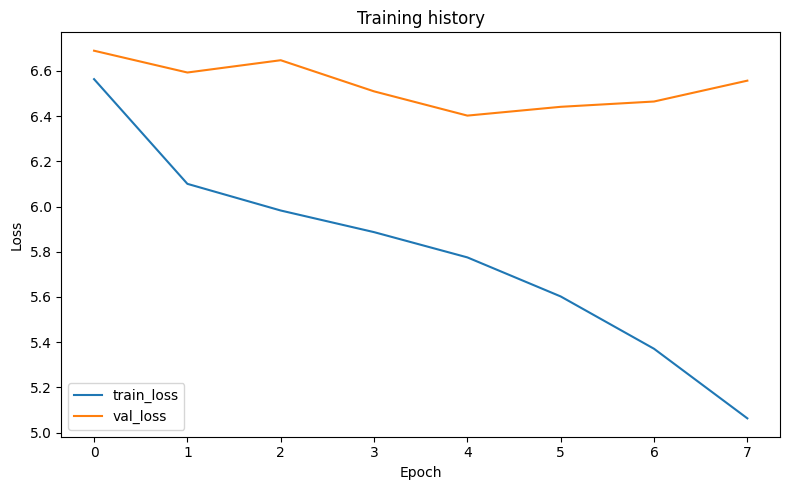

In [18]:
# Šioje celėje vykdomas pagrindinis modelio mokymo ciklas. Kiekvienoje epochoje modelis
# apmokomas, įvertinamas validacijos rinkinyje, išsaugomas geriausias modelis ir taikomas early
# stopping, jei validacijos klaida nebegerėja.

output_dir = ensure_dir(cfg.output_dir)
model_dir = ensure_dir(output_dir / "model")

history = {
    "train_loss": [],
    "val_loss": [],
    "epoch_time_sec": []
}

best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

start_time = time.time()

print("START TRAINING")

for epoch in range(1, cfg.num_epochs + 1):
    epoch_start = time.time()

    print(f"\n===== Epoch {epoch}/{cfg.num_epochs} =====")
    current_teacher_forcing = max(0.2, cfg.teacher_forcing_ratio * (0.9 ** (epoch - 1)))
    print(f"teacher_forcing_ratio={current_teacher_forcing:.3f}")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=cfg.device,
        grad_clip=cfg.grad_clip,
        teacher_forcing_ratio=current_teacher_forcing
    )

    val_loss = evaluate_loss(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
    )

    epoch_time = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["epoch_time_sec"].append(epoch_time)

    print(f"Epoch {epoch:02d}/{cfg.num_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | time={epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "vocab_token_to_idx": vocab.token_to_idx,
            "config": asdict(cfg),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "history": history,
        }

        torch.save(checkpoint, model_dir / "best_model.pt")
        print("  -> best model saved")
    else:
        patience_counter += 1
        print(f"  -> no improvement ({patience_counter}/{cfg.patience})")

        if patience_counter >= cfg.patience:
            print("Early stopping triggered.")
            break

total_time_sec = time.time() - start_time

training_summary = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_completed": len(history["train_loss"]),
    "total_training_time_sec": total_time_sec,
    "total_training_time_min": total_time_sec / 60,
    "history": history,
}

with open(output_dir / "training_summary.json", "w", encoding="utf-8") as f:
    json.dump(training_summary, f, ensure_ascii=False, indent=2)

print(f"\nTotal training time: {total_time_sec / 60:.2f} min")
print(f"Training summary saved to: {output_dir / 'training_summary.json'}")

save_training_plot(history, output_dir / "training_history.png", dpi=cfg.dpi)

In [19]:
# Čia įkeliamas geriausias išsaugotas modelis iš checkpoint failo. Atkuriamas žodynas, modelio
# struktūra ir svoriai, kad vėliau būtų galima atlikti galutinį vertinimą arba naudoti modelį
# prognozėms.

checkpoint = torch.load(model_dir / "best_model.pt", map_location=cfg.device)

loaded_vocab = Vocab(min_freq=cfg.min_freq)
loaded_vocab.token_to_idx = checkpoint["vocab_token_to_idx"]
loaded_vocab.idx_to_token = {idx: tok for tok, idx in loaded_vocab.token_to_idx.items()}

loaded_model = Seq2SeqSummarizer(
    vocab_size=len(loaded_vocab),
    emb_dim=cfg.emb_dim,
    hidden_dim=cfg.hidden_dim,
    num_layers=cfg.num_layers,
    dropout=cfg.dropout,
).to(cfg.device)

loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print("Loaded best model from epoch:", checkpoint["best_epoch"])
print("Best val loss:", checkpoint["best_val_loss"])

NameError: name 'model_dir' is not defined

In [20]:
# Šioje celėje modelis įvertinamas train, validation ir test rinkiniuose. Kiekvienam rinkiniui
# sugeneruojamos santraukos, apskaičiuojamos ROUGE metrikos, test rinkiniui papildomai gali būti
# skaičiuojamas BERTScore, o rezultatai išsaugomi į atskirus aplankus.

all_results = {}

split_map = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader,
}

for split_name, loader in split_map.items():
    print(f"\nProcessing {split_name}...")

    split_dir = ensure_dir(output_dir / split_name)

    pred_df = generate_predictions(
        model=loaded_model,
        loader=loader,
        vocab=loaded_vocab,
        cfg=cfg,
        split_name=split_name
    )

    pred_df = compute_rouge(pred_df)

    if split_name == "test" and cfg.compute_bertscore_on_test:
        pred_df = compute_bertscore(pred_df, cfg)

    metrics = build_metrics(pred_df)

    pred_df.to_csv(split_dir / "predictions.csv", index=False, encoding="utf-8")

    with open(split_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    print(metrics)

print("\nDone.")


Processing train...
{'num_samples': 5000, 'rouge1_f1_mean': 0.19521767896962308, 'rouge2_f1_mean': 0.031082512892774354, 'rougeL_f1_mean': 0.17227100629822628, 'rouge1_precision_mean': 0.3789050142917021, 'rouge1_recall_mean': 0.14221778066464022, 'rouge2_precision_mean': 0.05837861697496204, 'rouge2_recall_mean': 0.0231618386047787, 'rougeL_precision_mean': 0.3290630949795305, 'rougeL_recall_mean': 0.12647688292002343, 'source_words_mean': 95.82, 'reference_words_mean': 20.5566, 'prediction_words_mean': 11.9472}

Processing val...
{'num_samples': 818, 'rouge1_f1_mean': 0.17346624850967815, 'rouge2_f1_mean': 0.023789065641398634, 'rougeL_f1_mean': 0.155938736334319, 'rouge1_precision_mean': 0.3453075941999367, 'rouge1_recall_mean': 0.12650458656348076, 'rouge2_precision_mean': 0.04633423151149312, 'rouge2_recall_mean': 0.0178014353289835, 'rougeL_precision_mean': 0.30575398416652616, 'rougeL_recall_mean': 0.11462520837818609, 'source_words_mean': 91.64180929095355, 'reference_words_me

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10457.25it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


100%|██████████| 102/102 [00:01<00:00, 54.82it/s]


computing greedy matching.


100%|██████████| 52/52 [00:00<00:00, 173.76it/s]

done in 2.17 seconds, 378.13 sentences/sec
{'num_samples': 819, 'rouge1_f1_mean': 0.16922834981399665, 'rouge2_f1_mean': 0.021281415130565466, 'rougeL_f1_mean': 0.14996988146483634, 'rouge1_precision_mean': 0.337044796107895, 'rouge1_recall_mean': 0.12209792529530873, 'rouge2_precision_mean': 0.039683962435694706, 'rouge2_recall_mean': 0.015966806579384544, 'rougeL_precision_mean': 0.2939143190440268, 'rougeL_recall_mean': 0.10901992875547821, 'source_words_mean': 95.5079365079365, 'reference_words_mean': 20.017094017094017, 'prediction_words_mean': 11.708180708180707, 'bertscore_precision_mean': 0.42438891530036926, 'bertscore_recall_mean': 0.3801572024822235, 'bertscore_f1_mean': 0.40006354451179504}

Done.


In [20]:
# Ši celė įkelia išsaugotas testavimo prognozes ir parodo pirmus kelis pavyzdžius. Taip galima
# rankiniu būdu palyginti originalų dialogą, tikrą santrauką ir modelio sugeneruotą santrauką.

test_predictions = pd.read_csv(Path(cfg.output_dir) / "test" / "predictions.csv")
test_predictions[["source_text", "reference_summary", "predicted_summary", "rouge1_f1", "rougeL_f1"]].head(10)

,source_text,reference_summary,predicted_summary,rouge1_f1,rougeL_f1
0,"Hannah: Hey, do you have Betty's number? Amand...",Hannah needs Betty's number but Amanda doesn't...,jane and ' are going to the party .,0.086957,0.086957
1,Eric: MACHINE! Rob: That's so gr8! Eric: I kno...,Eric and Rob are going to watch a stand-up on ...,the and a are going to the the . . .,0.500000,0.400000
2,"Lenny: Babe, can you help me with something? B...",Lenny can't decide which trousers to buy. Bob ...,emily is going to the the . . . . . . .,0.114286,0.114286
3,"Will: hey babe, what do you want for dinner to...",Emma will be home soon and she will let Will k...,jake will pick up for dinner for dinner .,0.105263,0.105263
4,"Ollie: Hi , are you in Warsaw Jane: yes, just ...",Jane is in Warsaw. Ollie and Jane has a party....,jane is going to a and she ' s . . . . . . . .,0.156863,0.156863
5,"Benjamin: Hey guys, what are we doing with the...",Hilary has the keys to the apartment. Benjamin...,the and to to the to the the . . will go to th...,0.320000,0.266667
6,Max: Know any good sites to buy clothes from? ...,Payton provides Max with websites selling clot...,emily is going to buy a . . . . . .,0.055556,0.055556
7,Rita: I'm so bloody tired. Falling asleep at w...,Rita and Tina are bored at work and have still...,luke is at the at at at . . . .,0.100000,0.100000
8,"Beatrice: I am in town, shopping. They have ni...","Beatrice wants to buy Leo a scarf, but he does...",the is the the the the the the the the . . .,0.000000,0.000000
9,Ivan: hey eric Eric: yeah man Ivan: so youre c...,Eric doesn't know if his parents let him go to...,jane is going to to to the to . . .,0.206897,0.206897


In [21]:
# Čia sukuriamos funkcijos jau išsaugotam LSTM modeliui naudoti. load_saved_lstm_model įkelia
# modelį ir žodyną, o predict_with_saved_lstm leidžia pateikti naują dialogą ir gauti modelio
# sugeneruotą santrauką.

def load_saved_lstm_model(model_path, cfg):
    checkpoint = torch.load(model_path, map_location=cfg.device)

    vocab = Vocab(min_freq=cfg.min_freq)
    vocab.token_to_idx = checkpoint["vocab_token_to_idx"]
    vocab.idx_to_token = {idx: tok for tok, idx in vocab.token_to_idx.items()}

    model = Seq2SeqSummarizer(
        vocab_size=len(vocab),
        emb_dim=cfg.emb_dim,
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers,
        dropout=cfg.dropout,
    ).to(cfg.device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, vocab, checkpoint


@torch.no_grad()
def predict_with_saved_lstm(model_path, text, cfg):
    model, vocab, checkpoint = load_saved_lstm_model(model_path, cfg)

    tokens = simple_tokenize(text)[:cfg.max_src_len]
    src_ids = vocab.encode(tokens)

    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(cfg.device)
    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long).to(cfg.device)

    generated = model.generate(
    src_ids=src_tensor,
    src_lengths=src_lengths,
    max_len=cfg.max_generation_len,
    beam_size=1,
    length_penalty=1.0
    )

    prediction = decode_generated_tokens(generated[0].cpu().numpy(), vocab)
    return prediction

In [22]:
# Šioje celėje pateikiamas praktinis pavyzdys: sukuriamas trumpas dialogas, jis perduodamas
# išsaugotam modeliui, o modelis sugeneruoja santrauką. Tai parodo, kaip apmokytą modelį galima
# naudoti su nauju tekstu.

sample_text = """Amanda: Are we still meeting tomorrow?
John: Yes, at 10 in the library.
Amanda: Great, I will bring the notes.
John: Perfect, see you there."""

summary = predict_with_saved_lstm(
    Path(cfg.output_dir) / "model" / "best_model.pt",
    sample_text,
    cfg
)
print(summary)

C:\Users\User\AppData\Local\Temp\ipykernel_24824\3650301779.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=cfg.device)


the and the are meeting at the the . .


In [24]:
# Ši celė dar kartą suskaičiuoja modelio parametrus: bendrą parametrų skaičių, mokomus parametrus
# ir nemokomus parametrus. Tai naudinga modelio dydžiui ir sudėtingumui apibūdinti.

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return total, trainable, non_trainable

total, trainable, non_trainable = count_parameters(model)

print(f"Iš viso parametrų: {total:,}")
print(f"Mokomų parametrų: {trainable:,}")
print(f"Nemokomų parametrų: {non_trainable:,}")

Iš viso parametrų: 69,448,640
Mokomų parametrų: 69,448,640
Nemokomų parametrų: 0
